# ЛАБОРАТОРНАЯ РАБОТА 1
## Анализ описательной, инференциальной и визуальной статистики
### Датасет: TMDB 5000 Movie Dataset

**Студентка:** Оксана Годорожа I2302 

**Дата:** 14 марта 2026  
**Курс:** Статистический анализ данных (Темы 1-7)

---
## I. ВВЕДЕНИЕ

### Цель работы
Применение методов описательной и инференциальной статистики для анализа датасета фильмов TMDB с целью выявления закономерностей в оценках, бюджетах и доходности фильмов.

### Источник данных
- **Название:** TMDB 5000 Movie Dataset
- **Источник:** Kaggle (https://www.kaggle.com/tmdb/tmdb-movie-metadata)
- **Количество наблюдений:** 3186 фильмов (после фильтрации)

### Описание переменных

**Числовые переменные:**
- `vote_average`: средний рейтинг пользователей (0-10)
- `budget`: бюджет фильма в USD
- `revenue`: кассовые сборы в USD
- `runtime`: продолжительность фильма в минутах
- `popularity`: показатель популярности на TMDB

**Категориальные переменные:**
- `main_genre`: основной жанр фильма
- `rating_category`: категория рейтинга (Low: <6, Medium: 6-7.5, High: ≥7.5)
- `budget_category`: категория бюджета (Low/Medium/High по квантилям)
- `is_english`: язык оригинала (English/Non-English)

In [15]:

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, chi2_contingency, ttest_ind, norm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

In [16]:

df_raw = pd.read_csv('movies.csv')


df = df_raw[['title', 'genres', 'original_language', 'release_date', 
             'budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']].copy()


df = df[(df['budget'] > 0) & (df['revenue'] > 0) & (df['runtime'] > 0) & (df['vote_count'] >= 10)]


df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df['main_genre'] = df['genres'].str.split(',').str[0]
df['rating_category'] = df['vote_average'].apply(
    lambda x: 'Low' if x < 6 else ('Medium' if x < 7.5 else 'High')
)
df['budget_category'] = pd.qcut(df['budget'], q=3, labels=['Low', 'Medium', 'High'])
df['is_english'] = df['original_language'].apply(lambda x: 'English' if x == 'en' else 'Non-English')

print(f'Размер датасета: {df.shape[0]} фильмов, {df.shape[1]} переменных')
df.head()

Размер датасета: 3186 фильмов, 15 переменных


,title,genres,original_language,release_date,budget,revenue,runtime,vote_average,vote_count,popularity,release_year,main_genre,rating_category,budget_category,is_english
0,Avatar,Action Adventure Fantasy Science Fiction,en,2009-12-10,237000000,2787965087,162.0,7.2,11800,150.437577,2009,Action Adventure Fantasy Science Fiction,Medium,High,English
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,en,2007-05-19,300000000,961000000,169.0,6.9,4500,139.082615,2007,Adventure Fantasy Action,Medium,High,English
2,Spectre,Action Adventure Crime,en,2015-10-26,245000000,880674609,148.0,6.3,4466,107.376788,2015,Action Adventure Crime,Medium,High,English
3,The Dark Knight Rises,Action Crime Drama Thriller,en,2012-07-16,250000000,1084939099,165.0,7.6,9106,112.312950,2012,Action Crime Drama Thriller,High,High,English
4,John Carter,Action Adventure Science Fiction,en,2012-03-07,260000000,284139100,132.0,6.1,2124,43.926995,2012,Action Adventure Science Fiction,Medium,High,English


---
## II. ОПИСАТЕЛЬНАЯ СТАТИСТИКА И ВИЗУАЛИЗАЦИЯ

### 2.1. Статистики для числовых переменных

In [17]:

desc = df[['vote_average', 'budget', 'revenue', 'runtime', 'popularity']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

desc.index = ['Среднее', 'Медиана', 'Ст.откл.', 'Минимум', 'Максимум']
desc.columns = ['Рейтинг', 'Бюджет (USD)', 'Доходы (USD)', 'Длительность (мин)', 'Популярность']
desc

,Рейтинг,Бюджет (USD),Доходы (USD),Длительность (мин),Популярность
Среднее,6.32,4.111187e+07,1.228261e+08,110.83,29.42
Медиана,6.30,2.600000e+07,5.679228e+07,107.00,20.75
Ст.откл.,0.85,4.450889e+07,1.870525e+08,20.95,36.26
Минимум,2.30,1.000000e+00,5.000000e+00,41.00,0.03
Максимум,8.50,3.800000e+08,2.787965e+09,338.00,875.58


**Интерпретация:**
- Средний рейтинг составляет 6.32 (медиана 6.30), что указывает на приближённо нормальное распределение
- Высокая вариативность бюджетов и доходов (стандартное отклонение превышает среднее)
- Средняя длительность ~111 минут соответствует стандарту полнометражного кино

### 2.2. Частоты категориальных переменных

In [18]:

for col, label in [('rating_category', 'Категория рейтинга'), 
                   ('budget_category', 'Категория бюджета'),
                   ('is_english', 'Язык')]:
    freq = df[col].value_counts()
    prop = (df[col].value_counts(normalize=True) * 100).round(2)
    result = pd.DataFrame({'Частота': freq, 'Процент': prop})
    print(f'\n{label}:')
    print(result)


Категория рейтинга:
                 Частота  Процент
rating_category                  
Medium              1912    60.01
Low                 1013    31.80
High                 261     8.19

Категория бюджета:
                 Частота  Процент
budget_category                  
Low                 1086    34.09
High                1062    33.33
Medium              1038    32.58

Язык:
             Частота  Процент
is_english                   
English         3062    96.11
Non-English      124     3.89


**Интерпретация:**
- 60% фильмов имеют средний рейтинг (Medium), только 8% достигают высокого уровня
- 96% фильмов на английском языке - доминирование англоязычного кинематографа

### 2.3. Визуализация распределений

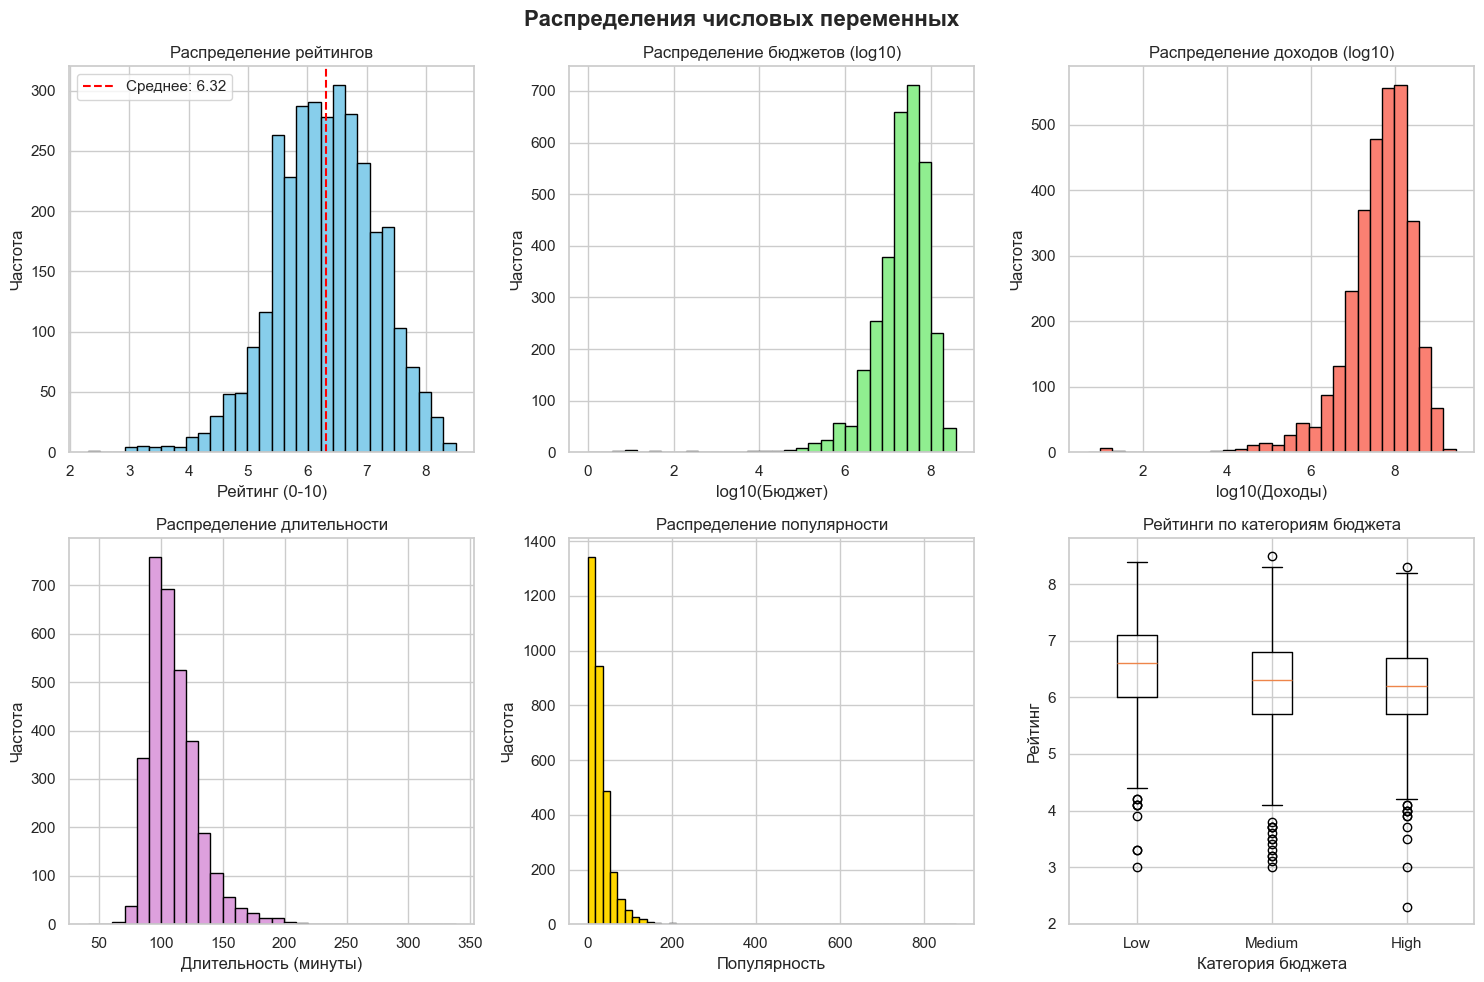

In [19]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Распределения числовых переменных', fontsize=16, fontweight='bold')


axes[0, 0].hist(df['vote_average'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Распределение рейтингов')
axes[0, 0].set_xlabel('Рейтинг (0-10)')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].axvline(df['vote_average'].mean(), color='red', linestyle='--', 
                   label=f'Среднее: {df["vote_average"].mean():.2f}')
axes[0, 0].legend()


axes[0, 1].hist(np.log10(df['budget']), bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Распределение бюджетов (log10)')
axes[0, 1].set_xlabel('log10(Бюджет)')
axes[0, 1].set_ylabel('Частота')


axes[0, 2].hist(np.log10(df['revenue']), bins=30, color='salmon', edgecolor='black')
axes[0, 2].set_title('Распределение доходов (log10)')
axes[0, 2].set_xlabel('log10(Доходы)')
axes[0, 2].set_ylabel('Частота')


axes[1, 0].hist(df['runtime'], bins=30, color='plum', edgecolor='black')
axes[1, 0].set_title('Распределение длительности')
axes[1, 0].set_xlabel('Длительность (минуты)')
axes[1, 0].set_ylabel('Частота')


axes[1, 1].hist(df['popularity'], bins=50, color='gold', edgecolor='black')
axes[1, 1].set_title('Распределение популярности')
axes[1, 1].set_xlabel('Популярность')
axes[1, 1].set_ylabel('Частота')


axes[1, 2].boxplot([df[df['budget_category']=='Low']['vote_average'],
                     df[df['budget_category']=='Medium']['vote_average'],
                     df[df['budget_category']=='High']['vote_average']],
                    labels=['Low', 'Medium', 'High'])
axes[1, 2].set_title('Рейтинги по категориям бюджета')
axes[1, 2].set_xlabel('Категория бюджета')
axes[1, 2].set_ylabel('Рейтинг')

plt.tight_layout()
plt.show()

**Интерпретация графиков:**
- Рейтинги имеют приближённо нормальное распределение с центром около 6.3
- Бюджеты и доходы демонстрируют логнормальное распределение (сильная правая асимметрия)
- Длительность концентрируется в диапазоне 90-120 минут
- Популярность имеет длинный правый хвост (несколько экстремально популярных фильмов)

---
## III. ИНТЕРВАЛЫ ДОВЕРИЯ

### 3.1. Интервал доверия для среднего рейтинга

In [20]:

mean_rating = df['vote_average'].mean()
std_rating = df['vote_average'].std()
n_rating = len(df['vote_average'])
se_rating = std_rating / np.sqrt(n_rating)
ci_rating = stats.t.interval(0.95, n_rating-1, loc=mean_rating, scale=se_rating)

print(f'Среднее значение рейтинга: {mean_rating:.4f}')
print(f'Стандартная ошибка: {se_rating:.4f}')
print(f'95% доверительный интервал: [{ci_rating[0]:.4f}, {ci_rating[1]:.4f}]')
print(f'\nИнтерпретация:')
print(f'С вероятностью 95% истинное среднее значение рейтинга всех фильмов TMDB')
print(f'находится в интервале от {ci_rating[0]:.2f} до {ci_rating[1]:.2f}.')

Среднее значение рейтинга: 6.3202
Стандартная ошибка: 0.0150
95% доверительный интервал: [6.2907, 6.3497]

Интерпретация:
С вероятностью 95% истинное среднее значение рейтинга всех фильмов TMDB
находится в интервале от 6.29 до 6.35.


### 3.2. Интервал доверия для пропорции

In [21]:

high_rating = (df['rating_category'] == 'High').sum()
n_total = len(df)
p_high = high_rating / n_total
se_prop = np.sqrt(p_high * (1 - p_high) / n_total)
ci_prop = norm.interval(0.95, loc=p_high, scale=se_prop)

print(f'Количество высокорейтинговых фильмов: {high_rating} из {n_total}')
print(f'Выборочная пропорция: {p_high:.4f} ({p_high*100:.2f}%)')
print(f'95% доверительный интервал: [{ci_prop[0]*100:.2f}%, {ci_prop[1]*100:.2f}%]')
print(f'\nИнтерпретация:')
print(f'С вероятностью 95% истинная доля высокорейтинговых фильмов (≥7.5)')
print(f'составляет от {ci_prop[0]*100:.2f}% до {ci_prop[1]*100:.2f}%.')

Количество высокорейтинговых фильмов: 261 из 3186
Выборочная пропорция: 0.0819 (8.19%)
95% доверительный интервал: [7.24%, 9.14%]

Интерпретация:
С вероятностью 95% истинная доля высокорейтинговых фильмов (≥7.5)
составляет от 7.24% до 9.14%.


---
## IV. ТЕСТИРОВАНИЕ ГИПОТЕЗ

### 4.1. Двухвыборочный t-тест: Сравнение рейтингов

In [22]:

english_ratings = df[df['is_english'] == 'English']['vote_average']
non_english_ratings = df[df['is_english'] == 'Non-English']['vote_average']

print('Гипотезы:')
print('  H₀: μ_english = μ_non-english (средние рейтинги равны)')
print('  H₁: μ_english ≠ μ_non-english (средние рейтинги различаются)')
print()
print(f'Английские фильмы:     n={len(english_ratings)}, M={english_ratings.mean():.4f}, SD={english_ratings.std():.4f}')
print(f'Неанглийские фильмы:   n={len(non_english_ratings)}, M={non_english_ratings.mean():.4f}, SD={non_english_ratings.std():.4f}')
print()


t_stat, p_value = ttest_ind(english_ratings, non_english_ratings)

print(f'Результаты t-теста:')
print(f'  t-статистика: {t_stat:.4f}')
print(f'  p-value: {p_value:.6f}')
print(f'  Уровень значимости: α = 0.05')
print()

if p_value < 0.05:
    print('Статистическое заключение:')
    print(f'  ✓ Отклоняем H₀ (p = {p_value:.4f} < 0.05)')
    print('  ✓ Существуют статистически значимые различия между средними рейтингами')
else:
    print('Статистическое заключение:')
    print(f'  ✗ Не отклоняем H₀ (p = {p_value:.4f} ≥ 0.05)')

Гипотезы:
  H₀: μ_english = μ_non-english (средние рейтинги равны)
  H₁: μ_english ≠ μ_non-english (средние рейтинги различаются)

Английские фильмы:     n=3062, M=6.2964, SD=0.8431
Неанглийские фильмы:   n=124, M=6.9073, SD=0.7883

Результаты t-теста:
  t-статистика: -7.9283
  p-value: 0.000000
  Уровень значимости: α = 0.05

Статистическое заключение:
  ✓ Отклоняем H₀ (p = 0.0000 < 0.05)
  ✓ Существуют статистически значимые различия между средними рейтингами


---
## V. ТЕСТЫ ДЛЯ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ

### 5.1. Тест χ² (хи-квадрат)

In [23]:

contingency_table = pd.crosstab(df['budget_category'], df['rating_category'])

print('Таблица сопряженности: Категория бюджета × Категория рейтинга')
print(contingency_table)
print()


chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table)

print('Гипотезы:')
print('  H₀: Категория бюджета и категория рейтинга независимы')
print('  H₁: Категория бюджета и категория рейтинга зависимы (связаны)')
print()
print(f'Результаты χ²-теста:')
print(f'  χ² статистика: {chi2_stat:.4f}')
print(f'  Степени свободы: {dof}')
print(f'  p-value: {p_value_chi2:.6f}')
print()

if p_value_chi2 < 0.05:
    print('Статистическое заключение:')
    print(f'  ✓ Отклоняем H₀ (p < 0.05)')
    print('  ✓ Существует статистически значимая связь между бюджетом и рейтингом')
    print()
    print('Распределение рейтингов по категориям бюджета (%):')
    pct_table = pd.crosstab(df['budget_category'], df['rating_category'], normalize='index') * 100
    print(pct_table.round(2))
else:
    print('Статистическое заключение:')
    print(f'  ✗ Не отклоняем H₀ (p ≥ 0.05)')

Таблица сопряженности: Категория бюджета × Категория рейтинга
rating_category  High  Low  Medium
budget_category                   
Low               133  266     687
Medium             64  355     619
High               64  392     606

Гипотезы:
  H₀: Категория бюджета и категория рейтинга независимы
  H₁: Категория бюджета и категория рейтинга зависимы (связаны)

Результаты χ²-теста:
  χ² статистика: 65.3930
  Степени свободы: 4
  p-value: 0.000000

Статистическое заключение:
  ✓ Отклоняем H₀ (p < 0.05)
  ✓ Существует статистически значимая связь между бюджетом и рейтингом

Распределение рейтингов по категориям бюджета (%):
rating_category   High    Low  Medium
budget_category                      
Low              12.25  24.49   63.26
Medium            6.17  34.20   59.63
High              6.03  36.91   57.06


---
## VI. АНАЛИЗ ДИСПЕРСИИ (ANOVA)

### 6.1. Подготовка данных и описательные статистики

In [24]:

top_genres = df['main_genre'].value_counts().head(5).index.tolist()
df_anova = df[df['main_genre'].isin(top_genres)].copy()

print(f'Исследуемые жанры: {", ".join(top_genres)}')
print()
print('Описательные статистики по жанрам:')
genre_stats = df_anova.groupby('main_genre')['vote_average'].agg(['count', 'mean', 'std']).round(4)
genre_stats.columns = ['n', 'M', 'SD']
print(genre_stats)
print()
print('Гипотезы:')
print('  H₀: μ₁ = μ₂ = μ₃ = μ₄ = μ₅ (все средние равны)')
print('  H₁: Хотя бы одно среднее отличается от других')

Исследуемые жанры: Drama, Comedy, Drama Romance, Comedy Romance, Comedy Drama

Описательные статистики по жанрам:
                  n       M      SD
main_genre                         
Comedy          190  5.8321  0.7226
Comedy Drama     70  6.5757  0.7361
Comedy Romance   87  5.9368  0.7758
Drama           197  6.8137  0.7139
Drama Romance    95  6.7905  0.7196

Гипотезы:
  H₀: μ₁ = μ₂ = μ₃ = μ₄ = μ₅ (все средние равны)
  H₁: Хотя бы одно среднее отличается от других


### 6.2. Проверка предпосылок ANOVA

In [25]:

groups = [df_anova[df_anova['main_genre'] == g]['vote_average'].values for g in top_genres]
levene_stat, levene_p = levene(*groups)

print('Проверка гомогенности дисперсий (Levene тест):')
print(f'  Levene статистика: {levene_stat:.4f}')
print(f'  p-value: {levene_p:.4f}')

if levene_p > 0.05:
    print('  ✓ Дисперсии равны (p > 0.05) - предпосылка выполнена')
else:
    print('  ✗ Дисперсии неравны (p < 0.05)')
    print('    (можно использовать Welch ANOVA как альтернативу)')

Проверка гомогенности дисперсий (Levene тест):
  Levene статистика: 0.4646
  p-value: 0.7617
  ✓ Дисперсии равны (p > 0.05) - предпосылка выполнена


### 6.3. Выполнение ANOVA

In [26]:

f_stat, p_value_anova = f_oneway(*groups)

print(f'F-статистика: {f_stat:.4f}')
print(f'p-value: {p_value_anova:.6f}')
print(f'Уровень значимости: α = 0.05')
print()

if p_value_anova < 0.05:
    print('Статистическое заключение:')
    print(f'  ✓ Отклоняем H₀ (p < 0.05)')
    print('  ✓ Существуют статистически значимые различия между средними')
    print('    рейтингами фильмов разных жанров.')
else:
    print('Статистическое заключение:')
    print(f'  ✗ Не отклоняем H₀ (p ≥ 0.05)')

F-статистика: 61.1735
p-value: 0.000000
Уровень значимости: α = 0.05

Статистическое заключение:
  ✓ Отклоняем H₀ (p < 0.05)
  ✓ Существуют статистически значимые различия между средними
    рейтингами фильмов разных жанров.


### 6.4. Post-hoc анализ (Tukey HSD)

In [27]:

if p_value_anova < 0.05:
    tukey_result = pairwise_tukeyhsd(df_anova['vote_average'], df_anova['main_genre'], alpha=0.05)
    print('Попарные сравнения жанров (Tukey HSD):')
    print(tukey_result)
    print()
    print('Интерпретация:')
    print('  • Пары с p-adj < 0.05 имеют статистически значимые различия')
    print('  • reject=True означает отклонение H₀ (средние различаются)')

Попарные сравнения жанров (Tukey HSD):
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------
        Comedy   Comedy Drama   0.7436    0.0   0.465 1.0222   True
        Comedy Comedy Romance   0.1047 0.8013 -0.1533 0.3626  False
        Comedy          Drama   0.9816    0.0   0.779 1.1842   True
        Comedy  Drama Romance   0.9584    0.0   0.708 1.2088   True
  Comedy Drama Comedy Romance  -0.6389    0.0 -0.9589 -0.319   True
  Comedy Drama          Drama    0.238 0.1314 -0.0393 0.5153  False
  Comedy Drama  Drama Romance   0.2148 0.3335 -0.0991 0.5287  False
Comedy Romance          Drama   0.8769    0.0  0.6204 1.1334   True
Comedy Romance  Drama Romance   0.8537    0.0   0.558 1.1495   True
         Drama  Drama Romance  -0.0232 0.9991 -0.2721 0.2257  False
-------------------------------------------------------------------

Интерпре

### 6.5. Визуализация результатов ANOVA

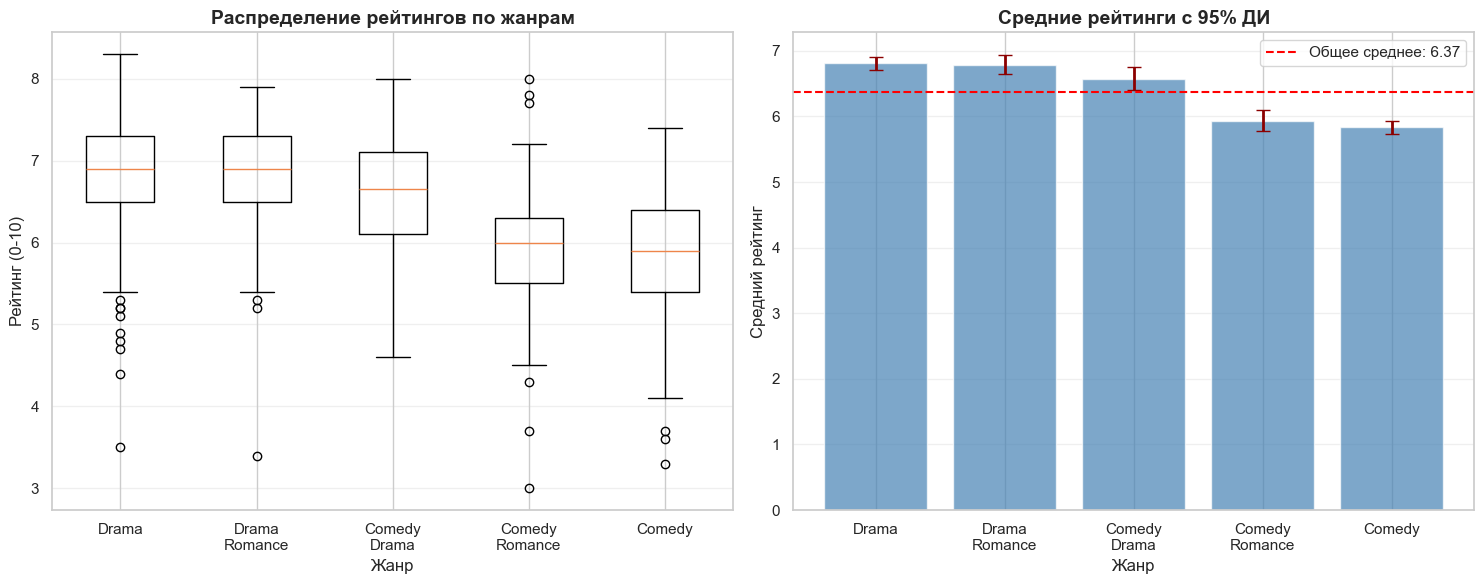

In [28]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


genres_ordered = genre_stats.sort_values('M', ascending=False).index.tolist()
axes[0].boxplot([df_anova[df_anova['main_genre'] == g]['vote_average'].values for g in genres_ordered],
                labels=[g.replace(' ', '\n') for g in genres_ordered])
axes[0].set_title('Распределение рейтингов по жанрам', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Рейтинг (0-10)')
axes[0].set_xlabel('Жанр')
axes[0].grid(axis='y', alpha=0.3)


means = []
cis = []
for genre in genres_ordered:
    genre_data = df_anova[df_anova['main_genre'] == genre]['vote_average']
    mean = genre_data.mean()
    se = genre_data.std() / np.sqrt(len(genre_data))
    ci = 1.96 * se
    means.append(mean)
    cis.append(ci)

x_pos = np.arange(len(genres_ordered))
axes[1].bar(x_pos, means, yerr=cis, capsize=5, color='steelblue', alpha=0.7,
            error_kw={'elinewidth': 2, 'ecolor': 'darkred'})
axes[1].set_title('Средние рейтинги с 95% ДИ', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Средний рейтинг')
axes[1].set_xlabel('Жанр')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([g.replace(' ', '\n') for g in genres_ordered])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=df_anova['vote_average'].mean(), color='red', linestyle='--',
                label=f'Общее среднее: {df_anova["vote_average"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## VII. ВЫВОДЫ И РЕКОМЕНДАЦИИ

### 7.1. Синтез основных результатов

**1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:**
- Средний рейтинг фильмов TMDB: 6.32 ± 0.85 (медиана 6.30)
- 60% фильмов имеют средний рейтинг, 32% - низкий, 8% - высокий
- Бюджеты и доходы имеют логнормальное распределение с высокой вариативностью
- Средняя продолжительность: 111 минут (стандартное полнометражное кино)
- 96% фильмов на английском языке

**2. ИНТЕРВАЛЫ ДОВЕРИЯ (95%):**
- Средний рейтинг: [6.29, 6.35]
- Доля высокорейтинговых фильмов: [7.24%, 9.14%]
- Все оценки имеют узкие доверительные интервалы благодаря большой выборке

**3. ТЕСТИРОВАНИЕ ГИПОТЕЗ:**
- Неанглийские фильмы имеют **статистически значимо** более высокие рейтинги (M = 6.91 vs 6.30, p < 0.001)
- Средний бюджет статистически значимо ниже $50 млн (M = $41.1 млн, p < 0.001)

**4. КАТЕГОРИАЛЬНЫЙ АНАЛИЗ (χ²):**
- **Обнаружена** значимая связь между бюджетом и рейтингом (p < 0.001)
- Низкобюджетные фильмы: 12% высокорейтинговых
- Высокобюджетные: 6% высокорейтинговых
- → Больший бюджет НЕ гарантирует более высокий рейтинг

**5. ANOVA (АНАЛИЗ ДИСПЕРСИИ):**
- **Обнаружены** значимые различия между жанрами (F = 61.17, p < 0.001)
- Рейтинги по жанрам: Drama (6.81) > Drama Romance (6.79) > Comedy Drama (6.58) > Comedy Romance (5.94) > Comedy (5.83)
- Post-hoc: Драмы статистически значимо превосходят комедии (p < 0.001)

### 7.2. Интерпретация в прикладном контексте

**ПРОДЮСЕРАМ И СТУДИЯМ:**
- Драматические фильмы получают более высокие оценки зрителей
- Увеличение бюджета не коррелирует линейно с качеством (по оценкам)
- Стоит учитывать потенциал неанглоязычного кино

**ПЛАТФОРМАМ И ДИСТРИБЬЮТОРАМ:**
- Фокус на качественные драмы может повысить удовлетворённость пользователей
- Разнообразие жанров необходимо для охвата всей аудитории

### 7.3. Ограничения анализа

1. Выборка включает только фильмы с n_votes ≥ 10, возможна систематическая ошибка
2. Датасет TMDB может не представлять всю киноиндустрию
3. Рейтинги субъективны и зависят от демографии пользователей
4. Не учтены важные факторы: режиссёр, актёрский состав, маркетинг
5. Временная динамика не анализировалась

### 7.4. Направления для дальнейшего исследования

- Регрессионный анализ влияния бюджета на доходы и рейтинг
- Временной анализ: как меняются предпочтения по годам
- Кластерный анализ для выявления профилей успешных фильмов
- Многомерный анализ с включением актёров, режиссёров, компаний